<a href="https://colab.research.google.com/github/Mytros/DS_ML_homework/blob/main/HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83_Dmytro_Koval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
raw_df = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/train.csv")

target_col = "Exited"  # target
input_cols = [col for col in raw_df.columns if col != target_col]

train_df, val_df = split_train_val(raw_df, target_col=target_col)
cat_cols = train_df.select_dtypes(include='object').columns.tolist()

# separate def
train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [5]:
# convert object to category
for col in train_inputs.select_dtypes(include='object').columns:
    train_inputs[col] = train_inputs[col].astype('category')

for col in val_inputs.select_dtypes(include='object').columns:
    val_inputs[col] = val_inputs[col].astype('category')


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [6]:
train_df.dtypes

,0
id,int64
CustomerId,float64
Surname,object
CreditScore,float64
Geography,object
Gender,object
Age,float64
Tenure,float64
Balance,float64
NumOfProducts,float64


In [7]:
print(train_inputs.dtypes[train_inputs.dtypes == "object"])


Series([], dtype: object)


In [10]:
?XGBClassifier

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Initializing
xgb_model = XGBClassifier(
    max_depth=3,
    n_estimators=10,
    learning_rate=0.1,
    enable_categorical=True,  # categorical
    use_label_encoder=False,  # for suppress warning
    missing=np.nan,           # nans !!!
    device='cuda',            #  'cpu' if without GPU
    tree_method='hist',       #
    random_state=42
)

# Training
xgb_model.fit(train_inputs, train_targets)

# predict proba
train_probs = xgb_model.predict_proba(train_inputs)[:, 1]
val_probs = xgb_model.predict_proba(val_inputs)[:, 1]

# AUROC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

# classes predict + metrics
train_preds = xgb_model.predict(train_inputs)
val_preds = xgb_model.predict(val_inputs)

print("\nTrain Classification Report:")
print(classification_report(train_targets, train_preds, digits=4))

print("Validation Classification Report:")
print(classification_report(val_targets, val_preds, digits=4))


Train AUROC: 0.9198
Validation AUROC: 0.9098

Train Classification Report:
              precision    recall  f1-score   support

         0.0     0.8736    0.9868    0.9268      9558
         1.0     0.8953    0.4410    0.5909      2442

    accuracy                         0.8758     12000
   macro avg     0.8844    0.7139    0.7588     12000
weighted avg     0.8780    0.8758    0.8584     12000

Validation Classification Report:
              precision    recall  f1-score   support

         0.0     0.8684    0.9887    0.9247      2390
         1.0     0.9032    0.4131    0.5669       610

    accuracy                         0.8717      3000
   macro avg     0.8858    0.7009    0.7458      3000
weighted avg     0.8755    0.8717    0.8519      3000



/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:58:48] WARNING: /workspace/src/context.cc:49: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:58:48] WARNING: /workspace/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:58:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [12]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import accuracy_score

In [13]:
!pip install hyperopt

In [15]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import roc_auc_score

# objective AUROC
def objective(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        device='cuda',
        random_state=42,
        tree_method='hist',
        early_stopping_rounds=10
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False
    )

    val_preds_proba = clf.predict_proba(val_inputs)[:, 1]
    val_auc = roc_auc_score(val_targets, val_preds_proba)

    return {'loss': -val_auc, 'status': STATUS_OK}


In [16]:
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}


In [18]:
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# fix int
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Best hyperparameters:", best)


  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:55:48] WARNING: /workspace/src/context.cc:49: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:55:48] WARNING: /workspace/src/context.cc:203: XGBoost is not compiled with CUDA support.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:55:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



  5%|▌         | 1/20 [00:00<00:07,  2.61trial/s, best loss: -0.9324782221002812]

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:55:48] WARNING: /workspace/src/context.cc:49: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:55:48] WARNING: /workspace/src/context.cc:203: XGBoost is not compiled with CUDA support.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:55:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 10%|█         | 2/20 [00:00<00:07,  2.37trial/s, best loss: -0.9362075588174772]

...

 90%|█████████ | 18/20 [00:12<00:03,  1.57s/trial, best loss: -0.9369442348583579]

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:56:01] WARNING: /workspace/src/context.cc:49: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:56:01] WARNING: /workspace/src/context.cc:203: XGBoost is not compiled with CUDA support.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:56:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 95%|█████████▌| 19/20 [00:13<00:01,  1.20s/trial, best loss: -0.9369442348583579]

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:56:01] WARNING: /workspace/src/context.cc:49: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:56:01] WARNING: /workspace/src/context.cc:203: XGBoost is not compiled with CUDA support.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [07:56:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



100%|██████████| 20/20 [00:13<00:00,  1.44trial/s, best loss: -0.9369442348583579]
Best hyperparameters: {'colsample_bytree': np.float64(0.8474894160927245), 'gamma': np.float64(0.47388381507984634), 'learning_rate': np.float64(0.1122766490251703), 'max_depth': 4, 'min_child_weight': 8, 'n_estimators': 225, 'reg_alpha': np.float64(0.9930677261658871), 'reg_lambda': np.float64(0.008021858512082036), 'subsample': np.float64(0.6214756950897792)}


In [20]:
final_clf = xgb.XGBClassifier(
    **best,
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    device='cuda',
    random_state=42,
    tree_method='hist'
)

final_clf.fit(train_inputs, train_targets)

# predict proba
train_preds = final_clf.predict_proba(train_inputs)[:, 1]
val_preds = final_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_preds)
val_auc = roc_auc_score(val_targets, val_preds)

print(f"Final Train AUROC: {train_auc:.4f}")
print(f"Final Validation AUROC: {val_auc:.4f}")


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:58:25] WARNING: /workspace/src/context.cc:49: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:58:25] WARNING: /workspace/src/context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:58:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Final Train AUROC: 0.9619
Final Validation AUROC: 0.9322


Висновок:

Train AUROC: 0.9619

Validation AUROC: 0.9322

Порівняно з попередньою моделлю (AUROC ~0.91), ми отримали помітне покращення якості:

Validation AUROC зріс на ≈0.02, що свідчить про кращу здатність моделі відрізняти класи.

Різниця між Train і Validation AUROC залишається невеликою, що означає:

- Модель не переобучена (overfitting — помірний або відсутній)

- Добра узагальнююча здатність (generalization)

- Hyperopt-оптимізація виявилась ефективною і швидкою.

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [23]:
import lightgbm as lgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import roc_auc_score, classification_report

#  index category
cat_features = train_inputs.select_dtypes(include='category').columns.tolist()
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_features]



In [24]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        num_leaves=int(params['num_leaves']),
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        min_split_gain=params['min_split_gain'],
        random_state=42
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        eval_metric='auc',
        categorical_feature=cat_feature_indexes
    )

    val_probs = clf.predict_proba(val_inputs)[:, 1]
    val_auc = roc_auc_score(val_targets, val_probs)

    return {'loss': -val_auc, 'status': STATUS_OK}


In [25]:
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)
}


In [27]:
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# correct types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Best hyperparams: ", best)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002027 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [29]:
final_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    random_state=42
)

final_clf.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    eval_metric='auc',
    categorical_feature=cat_feature_indexes
)

# predict proba
train_probs = final_clf.predict_proba(train_inputs)[:, 1]
val_probs = final_clf.predict_proba(val_inputs)[:, 1]

# AUROC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Final LightGBM Train AUROC: {train_auc:.4f}")
print(f"Final LightGBM Validation AUROC: {val_auc:.4f}")

# classification report
val_preds = final_clf.predict(val_inputs)
print(classification_report(val_targets, val_preds, digits=4))


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

Значення трохи покращилися:

Final LightGBM Train AUROC: 0.9785

Final LightGBM Validation AUROC: 0.9350


5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [35]:
def make_lgb_objective(X_train, y_train, X_val, y_val, cat_feature_indexes):
    def objective(params):
        clf = lgb.LGBMClassifier(
            n_estimators=int(params['n_estimators']),
            learning_rate=params['learning_rate'],
            max_depth=int(params['max_depth']),
            num_leaves=int(params['num_leaves']),
            min_child_weight=params['min_child_weight'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            min_split_gain=params['min_split_gain'],
            random_state=42
        )

        clf.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric='auc',
            categorical_feature=cat_feature_indexes
        )

        val_probs = clf.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, val_probs)

        return {'loss': -val_auc, 'status': STATUS_OK}
    return objective


In [36]:
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)
}


In [37]:
from hyperopt import fmin, tpe, Trials

trials = Trials()
lgb_objective = make_lgb_objective(train_inputs, train_targets, val_inputs, val_targets, cat_feature_indexes)

best = fmin(fn=lgb_objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials) # max_evals = 10 default

# correct types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Best hyperparams:", best)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002012 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [39]:
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    random_state=42
)

final_lgb_clf.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    eval_metric='auc',
    categorical_feature=cat_feature_indexes
)

train_probs = final_lgb_clf.predict_proba(train_inputs)[:, 1]
val_probs = final_lgb_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Final LightGBM Train AUROC: {train_auc:.4f}")
print(f"Final LightGBM Validation AUROC: {val_auc:.4f}")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [41]:
# LGB
# 1. test dataset
test_df = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/test.csv")

# 2. category
for col in cat_features:
    test_df[col] = test_df[col].astype('category')

# 3. pred proba class 1
test_probs = final_lgb_clf.predict_proba(test_df)[:, 1]

# 4. submission template
submission = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/sample_submission.csv")

# 5. write predictions
submission['Exited'] = test_probs

# 6. Save
submission.to_csv("/content/drive/MyDrive/DS_ML/submissions/submission_boosting_lgb_v2.csv", index=False)
print("LGB Submission saved")


Submission saved


In [42]:
# XGB
# 1. test dataset
test_df = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/test.csv")

# 2. category
for col in cat_features:
    test_df[col] = test_df[col].astype('category')

# 3. pred proba class 1
test_probs_xgb = final_clf.predict_proba(test_df)[:, 1]

# 4.  submission template
submission_xgb = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/sample_submission.csv")

# 5. write predictions
submission_xgb['Exited'] = test_probs_xgb

# 6. Save
submission_xgb.to_csv("/content/drive/MyDrive/DS_ML/submissions/submission_boosting_xgb.csv", index=False)
print("XGBoost submission saved")


XGBoost submission saved


In [43]:
# predictions LGB
test_probs_lgb = final_lgb_clf.predict_proba(test_df)[:, 1]

# predictions XGB
test_probs_xgb = final_clf.predict_proba(test_df)[:, 1]

# Ensemble: average
ensemble_probs = 0.5 * test_probs_lgb + 0.5 * test_probs_xgb

# Save
submission_ensemble = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/sample_submission.csv")
submission_ensemble['Exited'] = ensemble_probs
submission_ensemble.to_csv("/content/drive/MyDrive/DS_ML/submissions/submission_ensemble_v2.csv", index=False)
print("Ensemble saved")


Ensemble saved


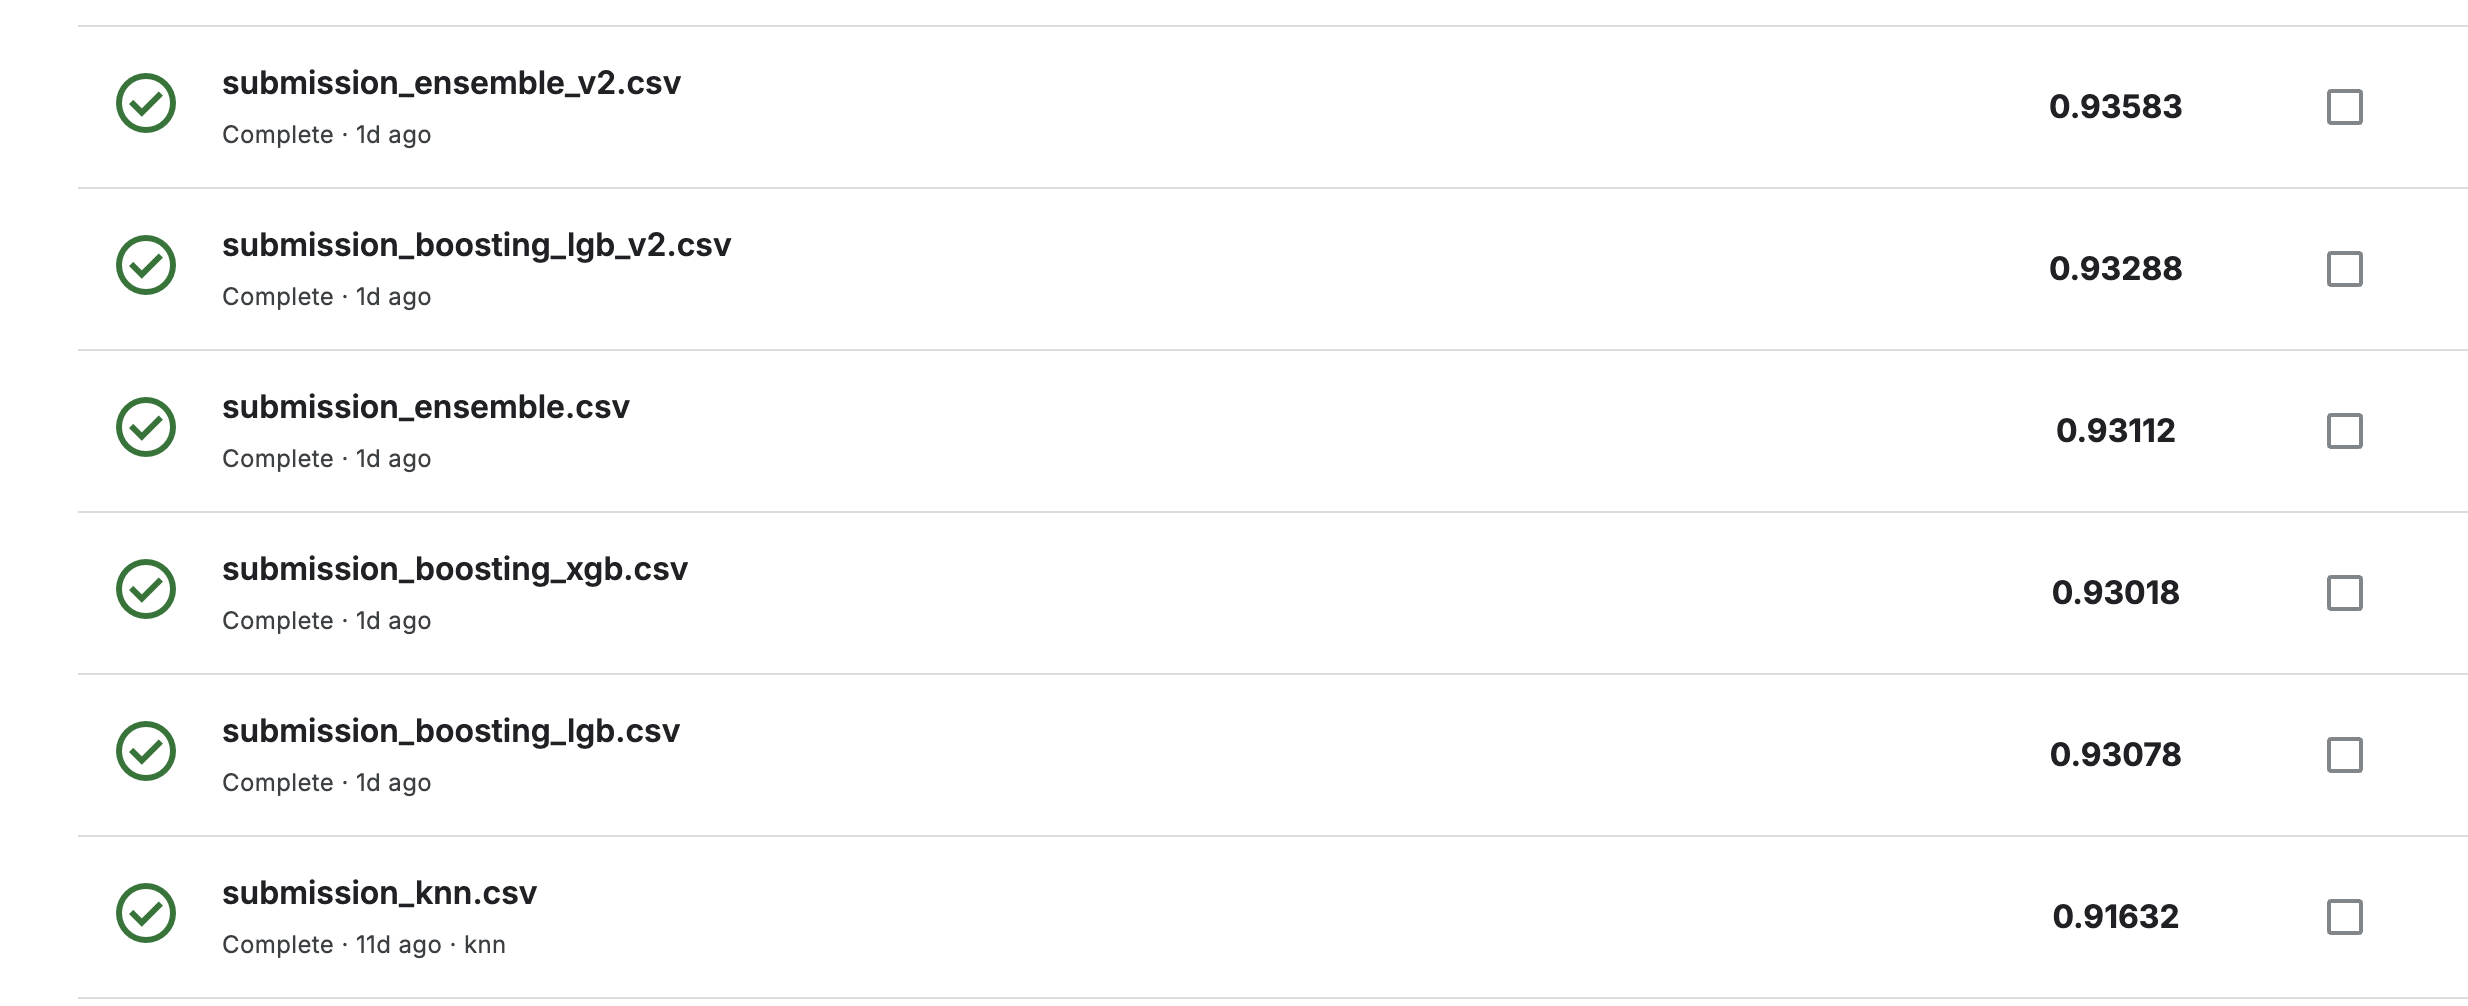

LGB показала себе краще, ніж XGB, але ще краще показала себе модель з предікшенами із середніми значеннями від XGB та LGB.

Взяв до розрахунків XGB, так як все ж таки ця модель краще генералізує.